In [15]:
import torch
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
from datasets import load_dataset
from peft import LoraConfig, get_peft_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [16]:
loc = "Salesforce/blip-image-captioning-base"
processor = BlipProcessor.from_pretrained(loc)
model = BlipForConditionalGeneration.from_pretrained(loc)
model = model.to(device)

In [17]:
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}"
    )

In [18]:
print_trainable_parameters(model)

trainable params: 247414076 || all params: 247414076 || trainable%: 100.0


In [19]:
from datasets import load_dataset
import json
import os

# Load dataset
dataset = load_dataset("imagefolder", data_dir="datasets", split="train")

# Load metadata
metadata_path = "datasets/metadata.json"
if os.path.exists(metadata_path):
    with open(metadata_path, "r") as f:
        metadata = json.load(f)
else:
    raise FileNotFoundError("metadata.json not found!")

# Print metadata keys (to check if file names match)
print("Metadata keys:", list(metadata.keys())[:5])  # Print first 5 keys for debugging

# Function to add text descriptions
def add_text(example):
    # Convert filename path format (fixes Windows/Linux path differences)
    file_name = os.path.basename(example["image"].filename)  # Extract "001.png"
    file_path = f"images/{file_name}"  # Match JSON key format

    # Debugging: Print file name and expected key
    print(f"Looking for: {file_path}")

    # Assign text from metadata, default to "No description available"
    example["text"] = metadata.get(file_path, "No description available")
    return example

# Apply function
dataset = dataset.map(add_text)

# Print results
print(dataset)
for i in range(6):
    print(dataset[i])  # Should now show {'image': ..., 'text': "Robot moves forward with wave gait."}


Metadata keys: ['images/001.png', 'images/002.png', 'images/003.png', 'images/004.png', 'images/005.png']
Dataset({
    features: ['image', 'text'],
    num_rows: 6
})
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=251x499 at 0x203583A2B50>, 'text': {'Body Movement': {'v_rot': 0.32, 'vx': 0.2, 'vy': -0.04}, 'Body Position': {'pos_x': 0.06, 'pos_y': -0.09, 'pos_z': 0.17}, 'Body Rotation': {'pitch': -0.69, 'roll': -6.2, 'yaw': 165.6}, 'Movement parameters': {'gait_select': 'tripod', 'step_duration': 1.49, 'step_height': 0.03}}}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=347x689 at 0x203583A2460>, 'text': {'Body Movement': {'v_rot': -0.23, 'vx': 0.83, 'vy': -0.07}, 'Body Position': {'pos_x': 0.03, 'pos_y': 0.14, 'pos_z': 0.06}, 'Body Rotation': {'pitch': 9.73, 'roll': -2.44, 'yaw': 42.82}, 'Movement parameters': {'gait_select': 'tripod', 'step_duration': 1.32, 'step_height': 0.03}}}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=287x4

In [20]:
class ImageCaptioningDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        encoding = self.processor(images=item["image"], text=item["text"], padding="max_length", return_tensors="pt")
        # remove batch dimension
        encoding = {k:v.squeeze() for k,v in encoding.items()}
        return encoding

In [21]:
config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=["query","value"],
)

peft_model = get_peft_model(model, config)

In [8]:
print_trainable_parameters(peft_model)

trainable params: 1179648 || all params: 248593724 || trainable%: 0.4745284720059948


In [9]:
train_dataset = ImageCaptioningDataset(dataset, processor)
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=2)

In [10]:
optimizer = torch.optim.AdamW(peft_model.parameters(), lr=5e-5)

device = "cuda" if torch.cuda.is_available() else "cpu"
peft_model.to(device)

peft_model.train()

for epoch in range(50):
  print("Epoch:", epoch)
  for idx, batch in enumerate(train_dataloader):
    input_ids = batch.pop("input_ids").to(device)
    pixel_values = batch.pop("pixel_values").to(device)

    outputs = peft_model(input_ids=input_ids,
                    pixel_values=pixel_values,
                    labels=input_ids)

    loss = outputs.loss

    print("Loss:", loss.item())

    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

Epoch: 0


We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Loss: 13.255389213562012
Loss: 13.277758598327637
Loss: 13.240715980529785
Epoch: 1
Loss: 13.239059448242188
Loss: 13.193756103515625
Loss: 13.19466781616211
Epoch: 2
Loss: 13.160359382629395
Loss: 13.147228240966797
Loss: 13.114880561828613
Epoch: 3
Loss: 13.057143211364746
Loss: 13.029699325561523
Loss: 12.975434303283691
Epoch: 4
Loss: 12.85873031616211
Loss: 12.750263214111328
Loss: 12.652130126953125
Epoch: 5
Loss: 12.494677543640137
Loss: 12.08337688446045
Loss: 11.87387752532959
Epoch: 6
Loss: 11.602761268615723
Loss: 11.505195617675781
Loss: 11.280993461608887
Epoch: 7
Loss: 11.159457206726074
Loss: 11.039326667785645
Loss: 10.989786148071289
Epoch: 8
Loss: 10.893903732299805
Loss: 10.844429969787598
Loss: 10.755051612854004
Epoch: 9
Loss: 10.723655700683594
Loss: 10.691388130187988
Loss: 10.661808013916016
Epoch: 10
Loss: 10.638514518737793
Loss: 10.604681015014648
Loss: 10.580595016479492
Epoch: 11
Loss: 10.563158988952637
Loss: 10.55048656463623
Loss: 10.53305721282959
Epoch

KeyboardInterrupt: 

In [14]:
print(dataset)

Dataset({
    features: ['image'],
    num_rows: 6
})


{'Body Movement': {'v_rot': 0.0, 'vx': 0.67, 'vy': 0.12}, 'Body Position': {'pos_x': 0.18, 'pos_y': -0.18, 'pos_z': 0.06}, 'Body Rotation': {'pitch': -5.76, 'roll': 9.2, 'yaw': 105.25}, 'Movement parameters': {'gait_select': 'tripod', 'step_duration': 1.82, 'step_height': 0.03}}


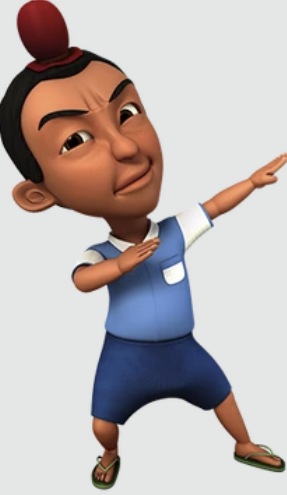

In [22]:
# load image
example = dataset[2]
print(example["text"])
image = example["image"]
image

In [14]:
# prepare image for the model
inputs = processor(images=image, return_tensors="pt").to(device)
pixel_values = inputs.pixel_values

generated_ids = peft_model.generate(pixel_values=pixel_values, max_length=50)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_caption)

a cartoon character with a baseball cap on his head


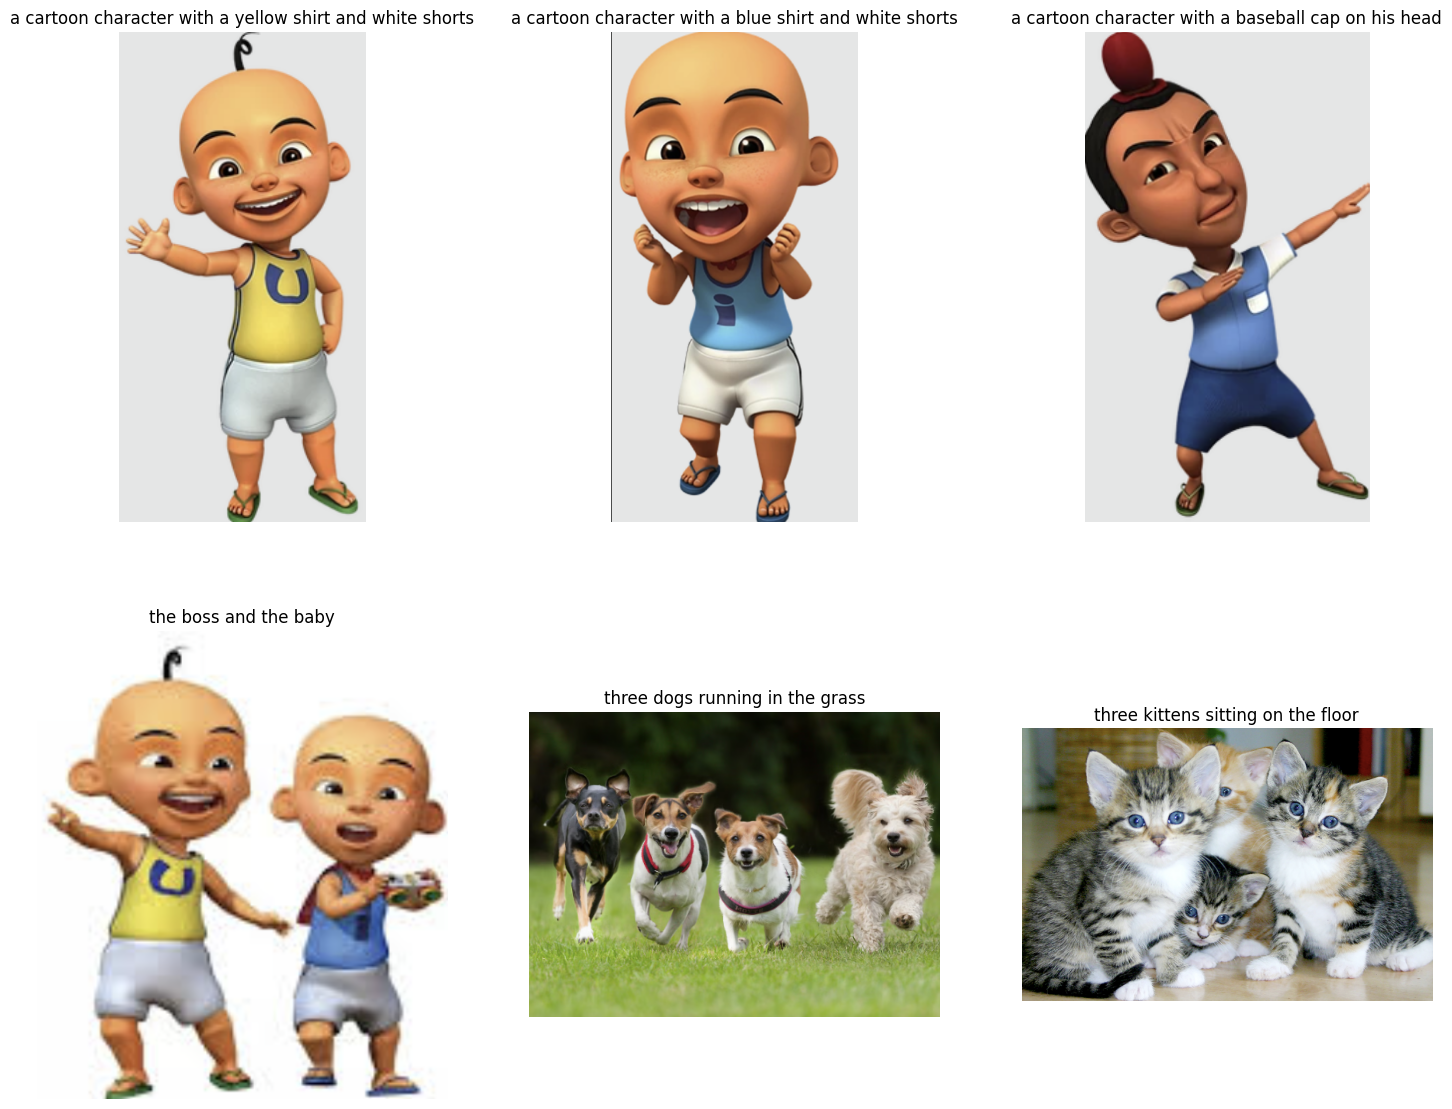

In [16]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(18, 14))

# prepare image for the model
for i, example in enumerate(dataset):
  image = example["image"]
  inputs = processor(images=image, return_tensors="pt").to(device)
  pixel_values = inputs.pixel_values

  generated_ids = peft_model.generate(pixel_values=pixel_values, max_length=50)
  generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
  fig.add_subplot(2, 3, i+1)
  plt.imshow(image)
  plt.axis("off")
  plt.title(f"{generated_caption}")